In [1]:
# FSPS / JWST F115W stellar M/L reference
# Values computed locally with FSPS in fsps_f115w_ml_ratio.ipynb.
# Unit: observed-frame JWST/NIRCam F115W stellar mass-to-flux conversion [Msun / nJy].
# Assumptions: z_lens=0.6575, SSP, dust2=0, age_grid_gyr=np.linspace(3.0, 6.7, 8),
# logzsol_grid=[-0.2, 0.0, 0.2]. These are SPS references, not lens-model constraints.

import pandas as pd

FSPS_F115W_ML_RATIO = {
    'Chabrier': {
        'min': 1.6579368322852848e6,
        'median': 2.6779500867208857e6,
        'max': 3.8983340134998499e6,
        'unit': 'Msun / nJy',
    },
    'Kroupa': {
        'min': 1.8130655747306140e6,
        'median': 2.9239963161227582e6,
        'max': 4.2551255702459561e6,
        'unit': 'Msun / nJy',
    },
    'Salpeter': {
        'min': 3.0763297610516166e6,
        'median': 4.9704783484526332e6,
        'max': 7.2594839173046760e6,
        'unit': 'Msun / nJy',
    },
}

fsps_f115w_ml_table = pd.DataFrame(FSPS_F115W_ML_RATIO).T
fsps_f115w_ml_table


,min,median,max,unit
Chabrier,1657936.832285,2677950.086721,3898334.0135,Msun / nJy
Kroupa,1813065.574731,2923996.316123,4255125.570246,Msun / nJy
Salpeter,3076329.761052,4970478.348453,7259483.917305,Msun / nJy


In [2]:
# Imaging-only LCDM Step 6: read posterior and sample mass profiles

import os
os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'

from pathlib import Path

import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from astropy.cosmology import FlatLambdaCDM
from astropy.io import fits
import astropy.units as u
from herculens.Coordinates.pixel_grid import PixelGrid
from herculens.MassModel import mass_model_base
from herculens.MassModel.mass_model import MassModel
from jax_lensing_profiles.MassModel.Profiles.CuspyNFW_ellipse_kappa import CuspyNFW_3D_fn
from jax_lensing_profiles.MassModel.Profiles.MGE import MGE
from matplotlib.lines import Line2D
from scipy.stats import binned_statistic
from tqdm.auto import tqdm


class CuspyNFWEllipseKappa(MGE):
    def __init__(self):
        super().__init__(
            CuspyNFW_3D_fn,
            'R_s',
            n_gauss=20,
            n_terms=28,
            sigma_start_mult=1 / 200,
            sigma_end_mult=20,
            three_d=True,
        )


mass_model_base.STRING_MAPPING['CUSPY_NFW_ELLIPSE_KAPPA'] = CuspyNFWEllipseKappa

NC_PATH = '/mnt/lustre/tianli/quasar_hmc/WFI2033_inferh0_step6_imaging_only_infer_LCDM_20260502_08/WFI2033_all_inferh0_step6_imaging_only_infer_LCDM.nc'
RAW_DATA_PATH = '../../Data/WFI2033/jw01198-o004_t004_nircam_clear-f115w_i2d.fits'
DATA_SUB_PATH = './result/result_ss=2_fullconcen_light_multimass_20260427_14/data_minus_lens_light_corrected_psf_ss=2_fullconcen_light_multimass.fits'
FIXED_FIVE_GAUSS_PATH = './result/result_ss=2_fullconcen_light_multimass_20260427_14/fixed_five_gaussians_corrected_psf_ss=2_fullconcen_light_multimass.npz'

POSTERIOR_VARS = [
    'mass_from_light_amp',
    'kappa_s_halo',
    'gammain_halo',
    'e_halo',
    'Rs_halo',
    'center_halo',
    'omega_m_cosmo',
    'H0_cosmo',
    'theta_E_g1',
    'theta_E_g2',
]

Z_LENS = 0.6575
N_POSTERIOR_SAMPLES = 500
N_RADIAL_BINS = 28
ARC_ARCSEC = 1.0
RNG = np.random.default_rng(20260505)

post = xr.open_dataset(NC_PATH, group='posterior', engine='h5netcdf')[POSTERIOR_VARS].load()
flat_post = {}
for name in POSTERIOR_VARS:
    arr = np.asarray(post[name].values)
    flat_post[name] = arr.reshape((arr.shape[0] * arr.shape[1],) + arr.shape[2:])

n_total_samples = flat_post['mass_from_light_amp'].shape[0]
sample_indices = RNG.choice(n_total_samples, size=N_POSTERIOR_SAMPLES, replace=False)

posterior_median = {name: np.median(values, axis=0) for name, values in flat_post.items()}
print(f'NC_PATH = {NC_PATH}')
print(f'posterior samples = {n_total_samples}')
print(f'H0 median = {posterior_median["H0_cosmo"]:.4f}')
print(f'Omega_m median = {posterior_median["omega_m_cosmo"]:.4f}')

with fits.open(RAW_DATA_PATH) as hdul:
    pix_scale = float(np.sqrt(hdul['SCI'].header['PIXAR_A2']))

with fits.open(DATA_SUB_PATH) as hdul:
    data_shape = hdul[0].data.shape

ny, nx = data_shape
half_size_x = nx * pix_scale / 2
half_size_y = ny * pix_scale / 2
pixel_grid = PixelGrid(
    nx=nx,
    ny=ny,
    ra_at_xy_0=-half_size_x + pix_scale / 2,
    dec_at_xy_0=-half_size_y + pix_scale / 2,
    transform_pix2angle=pix_scale * np.eye(2),
)
xgrid, ygrid = pixel_grid.pixel_coordinates
extent = pixel_grid.extent
xgrid_jnp = jnp.asarray(xgrid)
ygrid_jnp = jnp.asarray(ygrid)

fixed_five_gaussians = np.load(FIXED_FIVE_GAUSS_PATH)
# Step 6 stores the posterior deterministic stellar amplitudes in `mass_from_light_amp`.
# The fixed MGE geometry is the same five-Gaussian basis used by the Step 6 model.
light_sigma = np.asarray(fixed_five_gaussians['sigma'], dtype=float)
light_e1 = np.asarray(fixed_five_gaussians['e1'], dtype=float)
light_e2 = np.asarray(fixed_five_gaussians['e2'], dtype=float)
light_center_x = np.asarray(fixed_five_gaussians['center_x'], dtype=float)
light_center_y = np.asarray(fixed_five_gaussians['center_y'], dtype=float)

star_model = MassModel(['MULTI_GAUSSIAN_ELLIPSE_KAPPA'])
dm_model = MassModel(['CUSPY_NFW_ELLIPSE_KAPPA'])
sis_model = MassModel(['SIS', 'SIS'])
sis_single_model = MassModel(['SIS'])
G1_MASS_CENTER = (1.556, 1.299)
G2_MASS_CENTER = (2.145, -3.326)


def light_kwargs_from_mass_amp(mass_from_light_amp):
    return [{
        'amp': np.asarray(mass_from_light_amp, dtype=float),
        'sigma': light_sigma,
        'e1': light_e1,
        'e2': light_e2,
        'center_x': light_center_x,
        'center_y': light_center_y,
    }]


def dm_kwargs_from_values(kappa_s_halo, gammain_halo, Rs_halo, e_halo, center_halo):
    return [{
        'kappa_s': float(kappa_s_halo),
        'gamma': float(gammain_halo),
        'R_s': float(Rs_halo),
        'e1': float(e_halo[0]),
        'e2': float(e_halo[1]),
        'center_x': float(center_halo[0]),
        'center_y': float(center_halo[1]),
    }]


def sis_kwargs_from_values(theta_E_g1, theta_E_g2):
    return [{
        'theta_E': float(np.asarray(theta_E_g1).reshape(-1)[0]),
        'center_x': G1_MASS_CENTER[0],
        'center_y': G1_MASS_CENTER[1],
    }, {
        'theta_E': float(np.asarray(theta_E_g2).reshape(-1)[0]),
        'center_x': G2_MASS_CENTER[0],
        'center_y': G2_MASS_CENTER[1],
    }]


def kwargs_from_flat_index(i):
    light_kwargs = light_kwargs_from_mass_amp(flat_post['mass_from_light_amp'][i])
    dm_kwargs = dm_kwargs_from_values(
        flat_post['kappa_s_halo'][i],
        flat_post['gammain_halo'][i],
        flat_post['Rs_halo'][i],
        flat_post['e_halo'][i],
        flat_post['center_halo'][i],
    )
    return light_kwargs, dm_kwargs


median_light_kwargs = light_kwargs_from_mass_amp(posterior_median['mass_from_light_amp'])
median_dm_kwargs = dm_kwargs_from_values(
    posterior_median['kappa_s_halo'],
    posterior_median['gammain_halo'],
    posterior_median['Rs_halo'],
    posterior_median['e_halo'],
    posterior_median['center_halo'],
)
median_sis_kwargs = sis_kwargs_from_values(
    posterior_median['theta_E_g1'],
    posterior_median['theta_E_g2'],
)

light_mass = np.asarray(star_model.kappa(xgrid_jnp, ygrid_jnp, median_light_kwargs))
dark_mass = np.asarray(dm_model.kappa(xgrid_jnp, ygrid_jnp, median_dm_kwargs))
sis_mass = np.asarray(sis_model.kappa(xgrid_jnp, ygrid_jnp, median_sis_kwargs))
g1_mass = np.asarray(sis_single_model.kappa(xgrid_jnp, ygrid_jnp, [median_sis_kwargs[0]]))
g2_mass = np.asarray(sis_single_model.kappa(xgrid_jnp, ygrid_jnp, [median_sis_kwargs[1]]))
total_mass = light_mass + dark_mass
total_convergence_all = total_mass + sis_mass

radius = np.hypot(xgrid, ygrid).ravel()
radius_positive = radius[radius > 0]
r_edges = np.geomspace(radius_positive.min(), radius_positive.max(), N_RADIAL_BINS + 1)
centers = np.sqrt(r_edges[:-1] * r_edges[1:])


def radial_mean(image):
    return binned_statistic(radius, image.ravel(), statistic='mean', bins=r_edges).statistic


lm_component_profiles = []
for component_index in range(len(light_sigma)):
    component_amp = np.zeros_like(posterior_median['mass_from_light_amp'], dtype=float)
    component_amp[component_index] = posterior_median['mass_from_light_amp'][component_index]
    component_kwargs = light_kwargs_from_mass_amp(component_amp)
    component_mass = np.asarray(star_model.kappa(xgrid_jnp, ygrid_jnp, component_kwargs))
    lm_component_profiles.append(radial_mean(component_mass))
lm_component_profiles = np.asarray(lm_component_profiles)


def cumulative_sum(image):
    values = image.ravel()
    cumulative = np.empty(N_RADIAL_BINS)
    for i, r_out in enumerate(r_edges[1:]):
        cumulative[i] = values[radius <= r_out].sum()
    return cumulative


lm_profiles = np.empty((N_POSTERIOR_SAMPLES, N_RADIAL_BINS))
dm_profiles = np.empty((N_POSTERIOR_SAMPLES, N_RADIAL_BINS))
tm_profiles = np.empty((N_POSTERIOR_SAMPLES, N_RADIAL_BINS))
frac_profiles = np.empty((N_POSTERIOR_SAMPLES, N_RADIAL_BINS))

for row, sample_i in enumerate(tqdm(sample_indices, desc='posterior profiles')):
    light_kwargs_i, dm_kwargs_i = kwargs_from_flat_index(sample_i)
    light_i = np.asarray(star_model.kappa(xgrid_jnp, ygrid_jnp, light_kwargs_i))
    dark_i = np.asarray(dm_model.kappa(xgrid_jnp, ygrid_jnp, dm_kwargs_i))
    total_i = light_i + dark_i

    lm_profiles[row] = radial_mean(light_i)
    dm_profiles[row] = radial_mean(dark_i)
    tm_profiles[row] = radial_mean(total_i)

    lm_cum_i = cumulative_sum(light_i)
    dm_cum_i = cumulative_sum(dark_i)
    frac_profiles[row] = dm_cum_i / (lm_cum_i + dm_cum_i)


def profile_quantiles(samples):
    return np.nanpercentile(samples, [2.27, 16, 50, 84, 97.7], axis=0)


lm_q227, lm_q16, lm_p50, lm_q84, lm_q977 = profile_quantiles(lm_profiles)
dm_q227, dm_q16, dm_p50, dm_q84, dm_q977 = profile_quantiles(dm_profiles)
tm_q227, tm_q16, tm_p50, tm_q84, tm_q977 = profile_quantiles(tm_profiles)
frac_q227, frac_q16, frac_p50, frac_q84, frac_q977 = profile_quantiles(frac_profiles)



ERROR:2026-05-06 09:16:47,070:jax._src.xla_bridge:473: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/mnt/lustre2/shared_conda/envs/tianli/herculens_tian/lib/python3.13/site-packages/jax/_src/xla_bridge.py", line 471, in discover_pjrt_plugins
    plugin_module.initialize()
    ~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/mnt/lustre2/shared_conda/envs/tianli/herculens_tian/lib/python3.13/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
    ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/mnt/lustre2/shared_conda/envs/tianli/herculens_tian/lib/python3.13/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This p

NC_PATH = /mnt/lustre/tianli/quasar_hmc/WFI2033_inferh0_step6_imaging_only_infer_LCDM_20260502_08/WFI2033_all_inferh0_step6_imaging_only_infer_LCDM.nc
posterior samples = 64000
H0 median = 85.5501
Omega_m median = 0.2986


posterior profiles:   0%|          | 0/500 [00:00<?, ?it/s]

/mnt/lustre2/shared_conda/envs/tianli/herculens_tian/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


0.8769983173971377 arcsec
0.8769983173971377


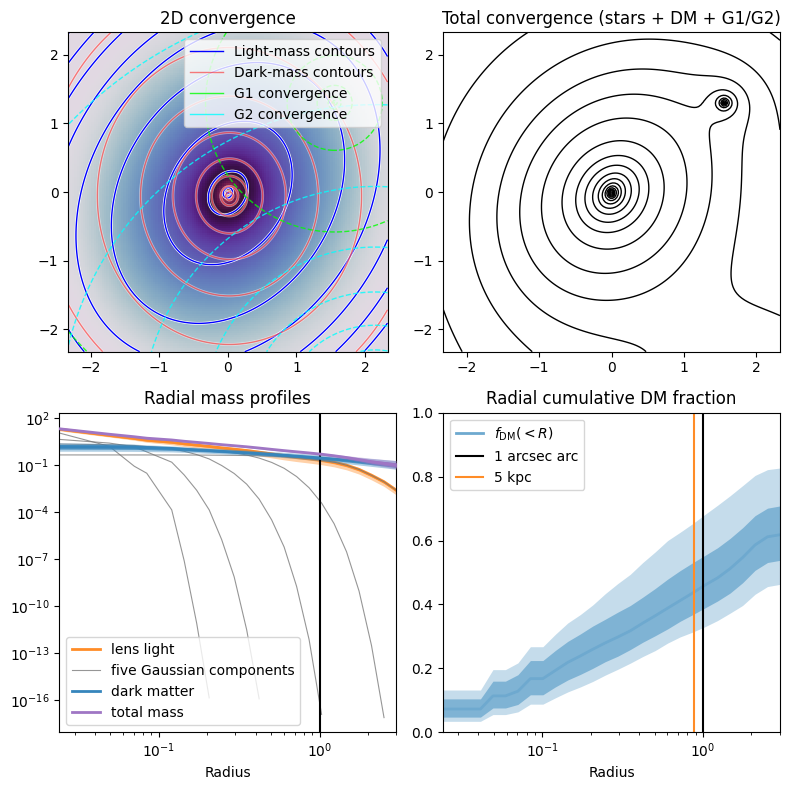

In [3]:
# Plot Step 6 convergence, radial profiles, and cumulative DM fraction

def finite_mask(*arrays):
    mask = np.ones_like(arrays[0], dtype=bool)
    for arr in arrays:
        mask &= np.isfinite(arr) & (arr > 0)
    return mask


light_proxy = Line2D([0], [0], color='blue', lw=1)
dark_proxy = Line2D([0], [0], color='red', lw=1, alpha=0.5)
g1_proxy = Line2D([0], [0], color='lime', lw=1, alpha=0.8)
g2_proxy = Line2D([0], [0], color='cyan', lw=1, alpha=0.8)

cosmo = FlatLambdaCDM(
    H0=float(posterior_median['H0_cosmo']) * u.km / u.s / u.Mpc,
    Om0=float(posterior_median['omega_m_cosmo']),
)
D_d = cosmo.angular_diameter_distance(Z_LENS)
theta_5kpc = (5 * u.kpc / D_d).to(u.arcsec, equivalencies=u.dimensionless_angles())
print(theta_5kpc)
print(theta_5kpc.value)

plt.figure(figsize=(8, 8))
plt.subplot(2, 2, 1)
plt.imshow(total_mass, norm='log', cmap='twilight', vmin=0.1, extent=extent)
plt.contour(np.log(light_mass), levels=10, colors='white', linestyles='solid', linewidths=2, extent=extent)
plt.contour(np.log(light_mass), levels=10, colors='blue', linestyles='solid', linewidths=1, extent=extent)
plt.contour(np.log(dark_mass), levels=10, colors='white', linestyles='solid', linewidths=2, extent=extent, alpha=0.5)
plt.contour(np.log(dark_mass), levels=10, colors='red', linestyles='solid', linewidths=1, extent=extent, alpha=0.5)
plt.contour(np.log(g1_mass), levels=6, colors='lime', linestyles='dashed', linewidths=1, extent=extent, alpha=0.8)
plt.contour(np.log(g2_mass), levels=6, colors='cyan', linestyles='dashed', linewidths=1, extent=extent, alpha=0.8)
plt.legend(
    handles=[light_proxy, dark_proxy, g1_proxy, g2_proxy],
    labels=['Light-mass contours', 'Dark-mass contours', 'G1 convergence', 'G2 convergence'],
    loc='upper right', frameon=True, handlelength=2.4,
)
plt.title('2D convergence')

plt.subplot(2, 2, 2)
plt.contour(np.log(total_convergence_all), levels=20, colors='black', linestyles='solid', linewidths=1, extent=extent)
plt.title('Total convergence (stars + DM + G1/G2)')

plt.subplot(2, 2, 3)
m_l = finite_mask(lm_p50, lm_q227, lm_q977)
plt.fill_between(centers[m_l], lm_q227[m_l], lm_q977[m_l], alpha=0.40, linewidth=0, color='#ff8c27', zorder=0)
plt.fill_between(centers[m_l], lm_q16[m_l], lm_q84[m_l], alpha=0.80, linewidth=0, color='#ff8c27', zorder=0.1)
plt.plot(centers[m_l], lm_p50[m_l], label='lens light', lw=2, color='#ff8c27', zorder=0.2)

for component_index, component_profile in enumerate(lm_component_profiles):
    m_component = finite_mask(component_profile)
    plt.plot(
        centers[m_component], component_profile[m_component],
        color='0.45', lw=0.8, alpha=0.75, zorder=0.5,
        label='five Gaussian components' if component_index == 0 else '_nolegend_',
    )

m_d = finite_mask(dm_p50, dm_q227, dm_q977)
plt.fill_between(centers[m_d], dm_q227[m_d], dm_q977[m_d], alpha=0.40, linewidth=0, color='#3685bc', zorder=2)
plt.fill_between(centers[m_d], dm_q16[m_d], dm_q84[m_d], alpha=0.80, linewidth=0, color='#3685bc', zorder=2.1)
plt.plot(centers[m_d], dm_p50[m_d], label='dark matter', lw=2, color='#3685bc', zorder=2.2)

m_t = finite_mask(tm_p50, tm_q227, tm_q977)
plt.fill_between(centers[m_t], tm_q227[m_t], tm_q977[m_t], alpha=0.40, linewidth=0, color='#9f76c4', zorder=3)
plt.fill_between(centers[m_t], tm_q16[m_t], tm_q84[m_t], alpha=0.80, linewidth=0, color='#9f76c4', zorder=3.1)
plt.plot(centers[m_t], tm_p50[m_t], label='total mass', lw=2, color='#9f76c4', zorder=3.2)

plt.axvline(ARC_ARCSEC, color='k', label='_nolegend_')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Radius')
plt.title('Radial mass profiles')
plt.legend(loc='best')
ax = plt.gca()
ax.set_xmargin(0)
plt.xlim(centers[m_t].min(), 3)

plt.subplot(2, 2, 4)
m_f = np.isfinite(centers) & (centers > 0) & np.isfinite(frac_p50) & np.isfinite(frac_q16) & np.isfinite(frac_q84)
plt.fill_between(centers[m_f], frac_q227[m_f], frac_q977[m_f], alpha=0.40, linewidth=0, label='_nolegend_', color='#6ea9cf')
plt.fill_between(centers[m_f], frac_q16[m_f], frac_q84[m_f], alpha=0.80, linewidth=0, label='_nolegend_', color='#6ea9cf')
plt.plot(centers[m_f], frac_p50[m_f], lw=2, label=r'$f_{\rm DM}(<R)$', color='#6ea9cf')

plt.axvline(ARC_ARCSEC, color='k', label='1 arcsec arc')
plt.axvline(theta_5kpc.value, color='#ff8c27', label='5 kpc')
plt.xscale('log')
plt.ylim(0, 1)
plt.xlabel('Radius')
plt.title('Radial cumulative DM fraction')
plt.legend(loc='upper left')
ax = plt.gca()
ax.set_xmargin(0)

Path('./Paper').mkdir(exist_ok=True)
plt.tight_layout()
plt.savefig('./Paper/dm_frac.pdf')
plt.show()



